# Lib

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import warnings
warnings.filterwarnings("ignore")

# Data

In [34]:
train_df = pd.read_csv("../../data/completed/train.csv")
train_df.head()

,source,target,label,name,ml_target
0,0,23977,1,Eiryyy,0.0
1,69,23977,1,shogochiai,0.0
2,1966,23977,1,kirimin,0.0
3,4422,23977,1,chezou,1.0
4,5631,23977,1,bkeating,0.0


# Graph

In [35]:
G = nx.from_pandas_edgelist(train_df, source='source', target='target')

print(f"Số lượng đỉnh trong đồ thị: {G.number_of_nodes()}")
print(f"Số lượng cạnh trong đồ thị: {G.number_of_edges()}")

Số lượng đỉnh trong đồ thị: 37700
Số lượng cạnh trong đồ thị: 462406


# Func

In [36]:
def compute_common_neighbors(g, u, v):
    if g.has_node(u) and g.has_node(v):
        return len(list(nx.common_neighbors(g, u, v)))
    return 0


def compute_jaccard(g, u, v):
    if g.has_node(u) and g.has_node(v) and u != v:
        preds = nx.jaccard_coefficient(g, [(u, v)])
        for u_, v_, p in preds:
            return p
    return 0.0


def compute_adamic_adar(g, u, v):
    if g.has_node(u) and g.has_node(v) and u != v:
        try:
            preds = nx.adamic_adar_index(g, [(u, v)])
            for u_, v_, p in preds:
                return p
        except ZeroDivisionError:
            return 0.0
    return 0.0


def compute_shortest_path(g, u, v):
    if g.has_node(u) and g.has_node(v):
        if nx.has_path(g, u, v):
            return nx.shortest_path_length(g, u, v)
    return -1


def compute_adamic_adar(g, u, v):
    if g.has_node(u) and g.has_node(v) and u != v:
        try:
            preds = nx.adamic_adar_index(g, [(u, v)])
            for u_, v_, p in preds:
                return p
        except ZeroDivisionError:
            return 0.0
    return 0.0

In [37]:
def get_top_connectors(g, top_n=5):
    degree_dict = dict(g.degree())
    degree_df = pd.DataFrame(
        list(degree_dict.items()), columns=["Node_ID", "Connections"]
    )
    top_connectors = degree_df.sort_values(by="Connections", ascending=False).head(
        top_n
    )
    return top_connectors


def get_strongest_ties(df, top_n=5):
    connected_pairs = df[df["label"] == 1].copy()
    strong_ties = connected_pairs.sort_values(by="JC", ascending=False).head(top_n)
    return strong_ties[["source", "target", "CN", "JC", "AA"]]


def recommend_new_connections(g, target_node, top_n=3):
    if not g.has_node(target_node):
        return "Node không tồn tại trong đồ thị!"
    unconnected_nodes = set(g.nodes()) - set(g.neighbors(target_node)) - {target_node}

    recommendations = []

    for node in unconnected_nodes:
        try:
            preds = nx.adamic_adar_index(g, [(target_node, node)])
            for u, v, p in preds:
                if p > 0:
                    recommendations.append(
                        {"Recommend_Node": v, "Adamic_Adar_Score": p}
                    )
        except ZeroDivisionError:
            continue

    rec_df = pd.DataFrame(recommendations)
    if not rec_df.empty:
        rec_df = rec_df.sort_values(by="Adamic_Adar_Score", ascending=False).head(top_n)
    return rec_df

# Show

In [38]:
train_df['CN'] = train_df.apply(lambda row: compute_common_neighbors(G, row['source'], row['target']), axis=1)
train_df['JC'] = train_df.apply(lambda row: compute_jaccard(G, row['source'], row['target']), axis=1)
train_df['AA'] = train_df.apply(lambda row: compute_adamic_adar(G, row['source'], row['target']), axis=1)
train_df['SPD'] = train_df.apply(lambda row: compute_shortest_path(G, row['source'], row['target']), axis=1)


In [39]:
train_df[['source', 'target', 'label', 'CN', 'JC', 'AA', 'SPD']].head()

,source,target,label,CN,JC,AA,SPD
0,0,23977,1,0,0.000000,0.000000,1
1,69,23977,1,0,0.000000,0.000000,1
2,1966,23977,1,1,0.017857,0.281266,1
3,4422,23977,1,1,0.014493,0.281266,1
4,5631,23977,1,0,0.000000,0.000000,1


# Analysis

In [40]:
top_devs = get_top_connectors(G)
top_devs

,Node_ID,Connections
21,31890,7656
36,27803,5702
421,35773,2727
17,19222,2349
1110,13638,1998


In [41]:
strongest_pairs = get_strongest_ties(train_df)
strongest_pairs

,source,target,CN,JC,AA
218387,25700,31165,32,0.457143,8.284260
95305,1526,29439,93,0.404348,27.317923
218468,16562,25700,27,0.402985,6.891952
218375,6784,31165,25,0.390625,6.431135
218245,31165,32308,28,0.388889,7.240518


In [42]:
user_to_recommend = 0
recommendations = recommend_new_connections(G, target_node=user_to_recommend)
recommendations

,Recommend_Node,Adamic_Adar_Score
645,31890,2.411600
570,27803,1.353792
497,23589,0.867456


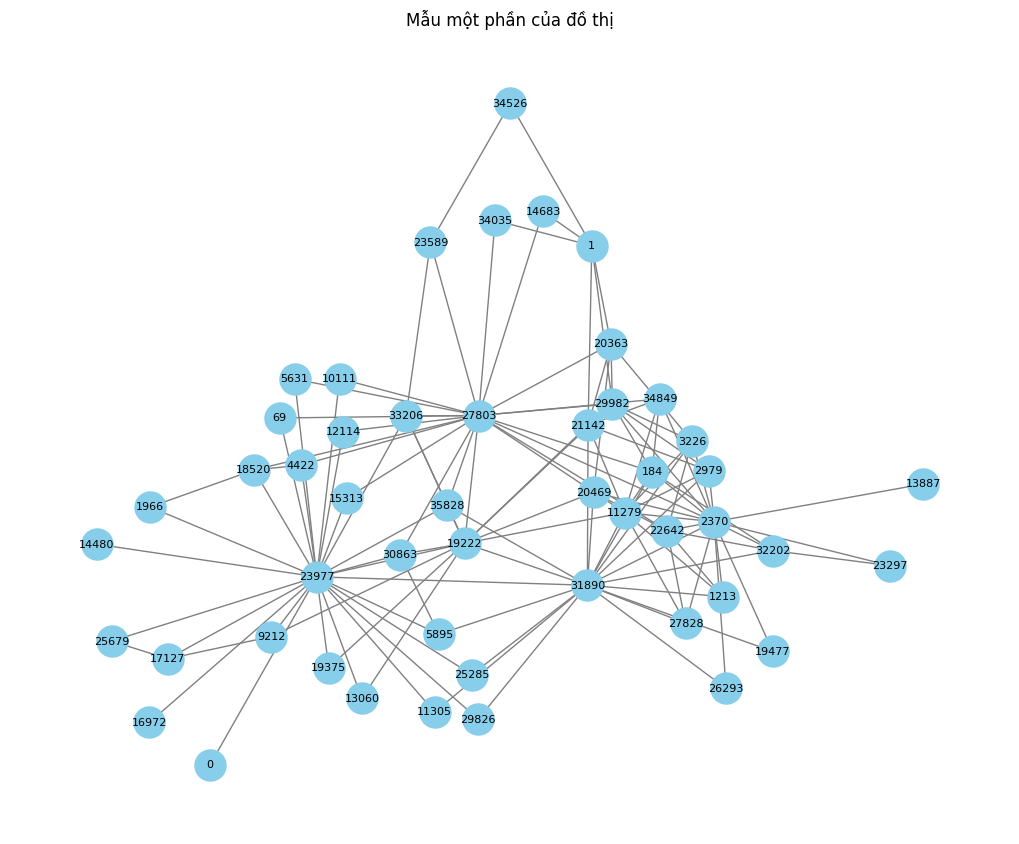

In [ ]:
sub_nodes = list(G.nodes())[:50]
sub_g = G.subgraph(sub_nodes)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_g, k=0.3, iterations=50)

nx.draw(
    sub_g,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=500,
    edge_color="gray",
    font_size=8,
    width=1.0,
)
plt.title("Mẫu một phần của đồ thị")
plt.show()